In [1]:
%matplotlib inline
# Cell 1 — parameters
LAT       = 16.8167   # Timbuktu
LON       = -2.9833
RADIUS_KM = 100       # buffer radius in km
LEVEL     = '06'      # '06' or '08'
EPSILON   = 0.001     # sliver threshold: drop basins covering < 0.1% of buffer area

In [2]:
# Cell 2 — imports and connection
import sys
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from matplotlib.colors import Normalize
from shapely import wkt as shapely_wkt
from pathlib import Path
from IPython.display import Image as IPImage, display

sys.path.insert(0, '../../../..')
from scripts.shared.db_utils import db_connect
import scripts.shared.db_utils as _dbu

conn = db_connect()
print('Connected:', conn.execute('SELECT current_database()').fetchone())

ROOT = Path(_dbu.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'areas'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUT}')

RADIUS_M = RADIUS_KM * 1000
TABLE    = f'public.basin{LEVEL}'

Connected: ('cedop',)
Output dir: /Users/karlg/Documents/repos/_edops/output/edop/areas


In [3]:
# Cell 3 — buffer resolver: geometry → weighted basin set
#
# Uses the precomputed geog column (geography type) so no runtime cast is needed.
# ST_Buffer radius is in true metres; ST_Area returns true m².
# weight = fraction of buffer area covered by each basin (not renormalised).

sql = f"""
WITH pt AS (
    SELECT ST_SetSRID(ST_MakePoint({LON}, {LAT}), 4326)::geography AS pt_geog
),
buf AS (
    SELECT
        ST_Buffer(pt_geog, {RADIUS_M}) AS buf_geog,
        ST_Area(ST_Buffer(pt_geog, {RADIUS_M})) AS buf_area_m2
    FROM pt
),
candidates AS (
    SELECT
        b.hybas_id,
        b.geom,
        ST_Area(ST_Intersection(b.geog, buf.buf_geog)) AS overlap_m2,
        buf.buf_area_m2
    FROM {TABLE} b, buf
    WHERE ST_Intersects(b.geog, buf.buf_geog)
)
SELECT
    hybas_id,
    overlap_m2 / buf_area_m2 AS weight,
    overlap_m2,
    buf_area_m2,
    geom
FROM candidates
WHERE overlap_m2 / buf_area_m2 >= {EPSILON}
ORDER BY weight DESC
"""

gdf = gpd.read_postgis(sql, conn, geom_col='geom').rename_geometry('geometry')
basin_set = gdf[['hybas_id', 'weight']].copy()

print(f'Weighted basin set — {len(basin_set)} basins (ε = {EPSILON})')
print(basin_set.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Weighted basin set — 9 basins (ε = 0.001)
       hybas_id  weight
1060041510.0000  0.2771
1060564960.0000  0.1738
1060040860.0000  0.1628
1060564740.0000  0.1367
1060551560.0000  0.1060
1060551770.0000  0.0876
1060043950.0000  0.0255
1060582960.0000  0.0181
1060582950.0000  0.0124


In [4]:
# Cell 4 — sanity: weight sum and land-coverage shortfall
total_weight = basin_set['weight'].sum()
shortfall    = 1.0 - total_weight

print(f'Weight sum : {total_weight:.4f}')
print(f'Shortfall  : {shortfall:.4f}  ← open water or outside BasinATLAS coverage')

if shortfall < 0:
    print('WARNING: weights exceed 1.0 — possible geometry overlap in basin table')
elif shortfall > 0.10:
    print('NOTE: >10% of buffer area not covered by any basin (expected near coasts/large lakes)')
else:
    print('OK: weight sum is within expected range')

Weight sum : 1.0000
Shortfall  : 0.0000  ← open water or outside BasinATLAS coverage
OK: weight sum is within expected range


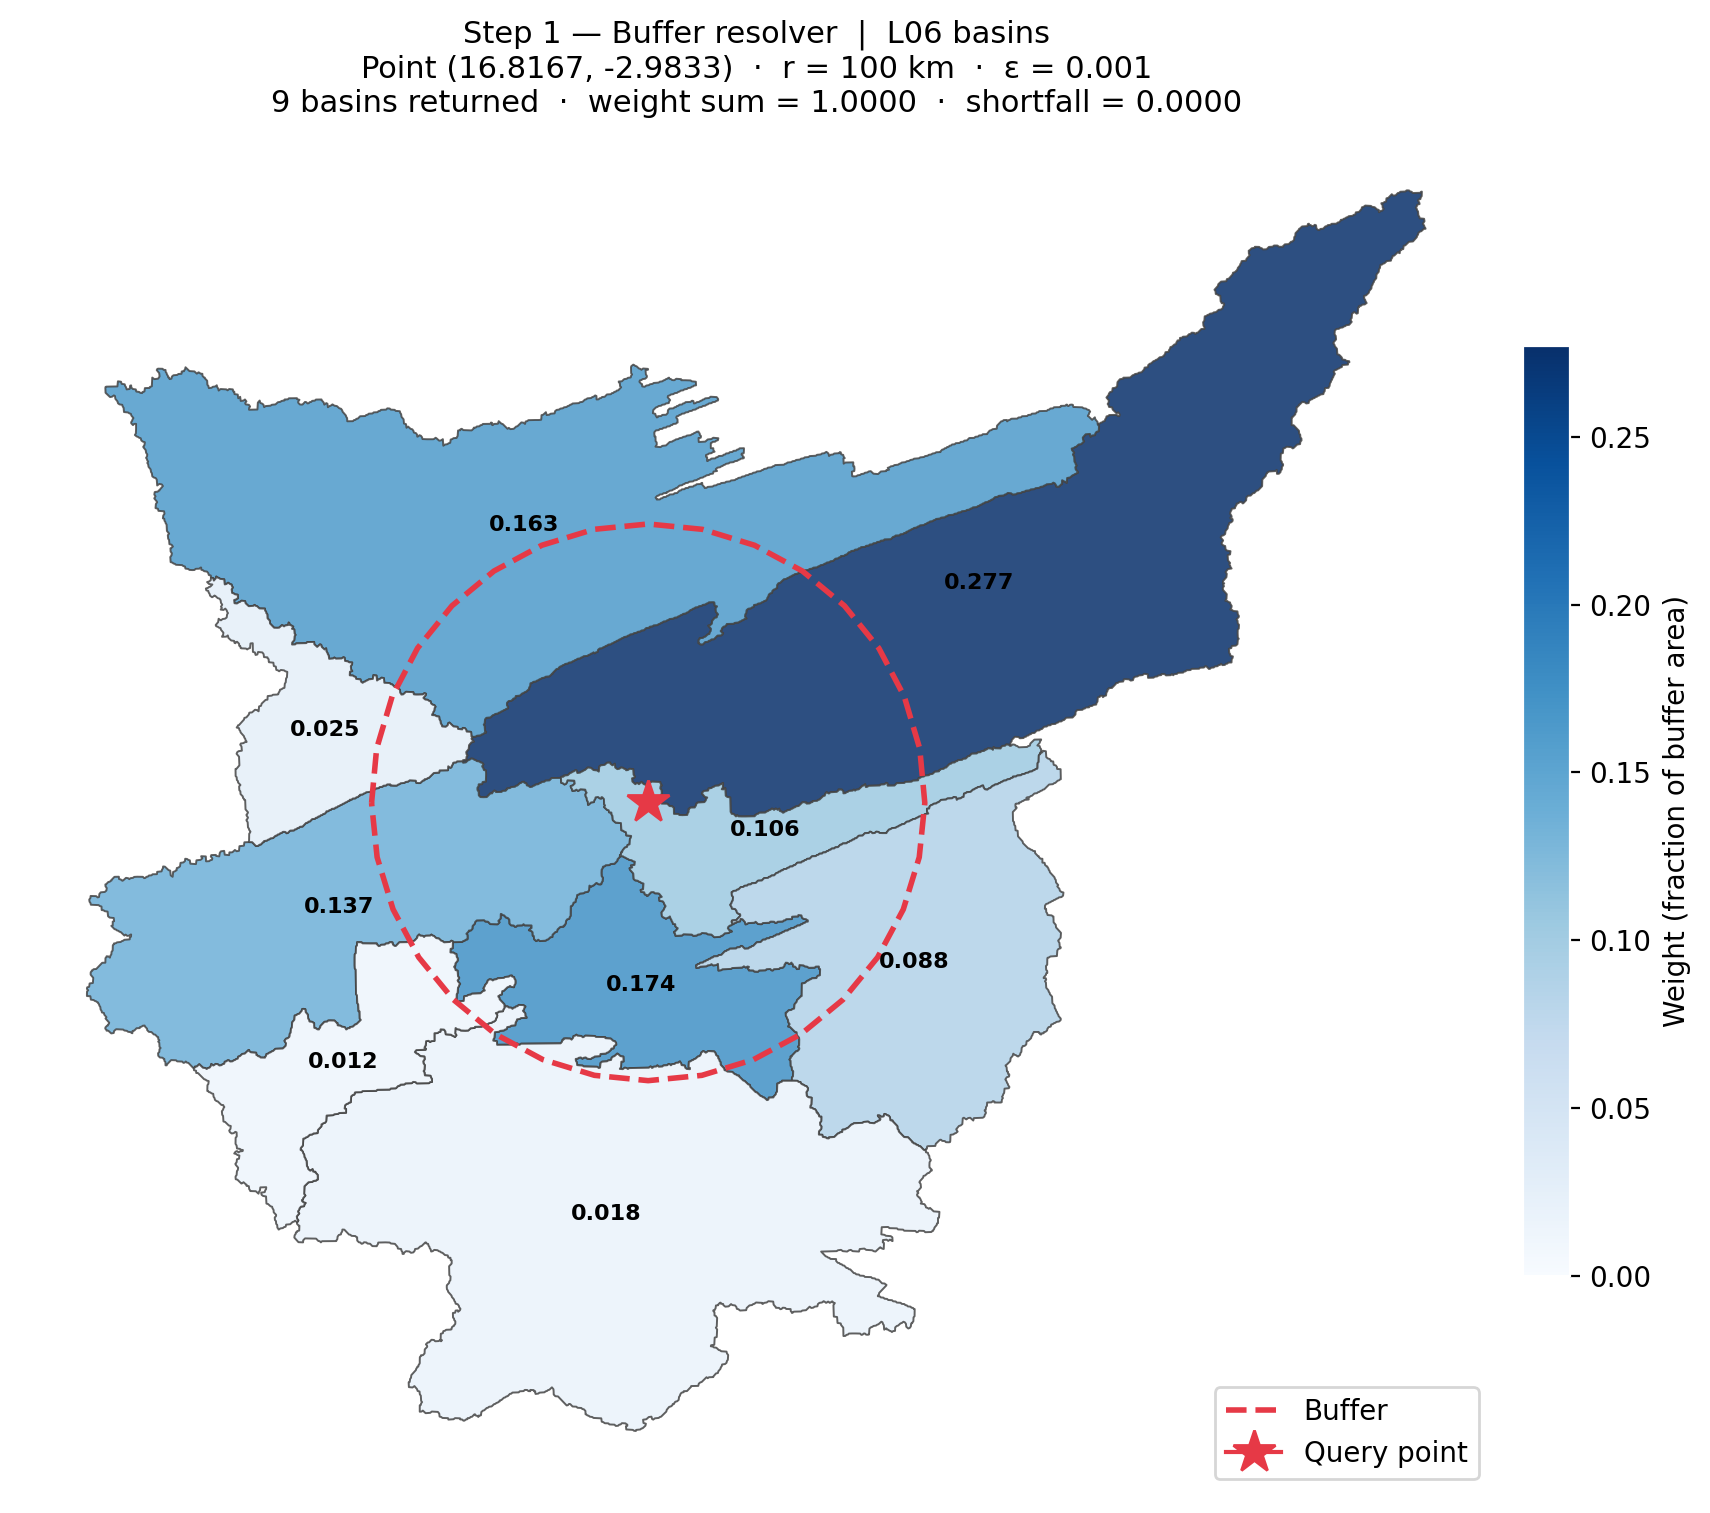

In [5]:
# Cell 5 — map: buffer circle + candidate basins coloured by weight

# Buffer polygon from PostGIS (geography-accurate circle → cast back to geometry for plotting)
buf_wkt = conn.execute(f"""
    SELECT ST_AsText(
        ST_Buffer(ST_SetSRID(ST_MakePoint({LON}, {LAT}), 4326)::geography, {RADIUS_M})::geometry
    )
""").fetchone()[0]
buf_geom = shapely_wkt.loads(buf_wkt)
buf_gdf  = gpd.GeoDataFrame(geometry=[buf_geom], crs='EPSG:4326')

norm = Normalize(vmin=0, vmax=gdf['weight'].max())

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('#e8eef4')

gdf.plot(column='weight', ax=ax, cmap='Blues', norm=norm,
         edgecolor='#444', linewidth=0.7, alpha=0.85)
buf_gdf.boundary.plot(ax=ax, color='#e63946', linewidth=2, linestyle='--', label='Buffer')
ax.plot(LON, LAT, marker='*', color='#e63946', markersize=16, zorder=5, label='Query point')

# Weight labels on each basin centroid
for _, row in gdf.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.text(cx, cy, f"{row['weight']:.3f}", fontsize=8, ha='center', va='center',
            color='black', fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.65)
cbar.set_label('Weight (fraction of buffer area)', fontsize=10, color='black')
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')

ax.set_title(
    f'Step 1 — Buffer resolver  |  L{LEVEL} basins\n'
    f'Point ({LAT}, {LON})  ·  r = {RADIUS_KM} km  ·  ε = {EPSILON}\n'
    f'{len(gdf)} basins returned  ·  weight sum = {total_weight:.4f}  ·  shortfall = {shortfall:.4f}',
    fontsize=11, color='black'
)
ax.set_axis_off()
legend = ax.legend(fontsize=10, loc='lower right', frameon=True)
for text in legend.get_texts():
    text.set_color('black')

outpath = OUT / f'step1_buffer_resolver_L{LEVEL}_{RADIUS_KM}km.png'
fig.savefig(outpath, dpi=200, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(IPImage(str(outpath)))

In [ ]:
# Cell 6 — close connection
conn.close()
print('Done.')